In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import random
import shutil
from tqdm import tqdm

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

2026-06-05 18:58:33.555343: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780685913.779768      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780685913.847202      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780685914.366109      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780685914.366147      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780685914.366150      58 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


Total classes: 32
Total images: 54049

Unique image modes found: ['L']
Unique image sizes found: [(64, 64)]

    class  count mode      size
0     ain   2114    L  (64, 64)
1      al   1343    L  (64, 64)
2   aleff   1672    L  (64, 64)
3      bb   1791    L  (64, 64)
4     dal   1634    L  (64, 64)
5     dha   1723    L  (64, 64)
6    dhad   1670    L  (64, 64)
7      fa   1955    L  (64, 64)
8    gaaf   1705    L  (64, 64)
9   ghain   1977    L  (64, 64)
10     ha   1592    L  (64, 64)
11    haa   1526    L  (64, 64)
12   jeem   1552    L  (64, 64)
13   kaaf   1774    L  (64, 64)
14   khaa   1607    L  (64, 64)
15     la   1746    L  (64, 64)
16   laam   1832    L  (64, 64)
17   meem   1765    L  (64, 64)
18    nun   1819    L  (64, 64)
19     ra   1659    L  (64, 64)
20   saad   1895    L  (64, 64)
21   seen   1638    L  (64, 64)
22  sheen   1507    L  (64, 64)
23     ta   1816    L  (64, 64)
24    taa   1838    L  (64, 64)
25   thaa   1766    L  (64, 64)
26   thal   1582    L  (64,

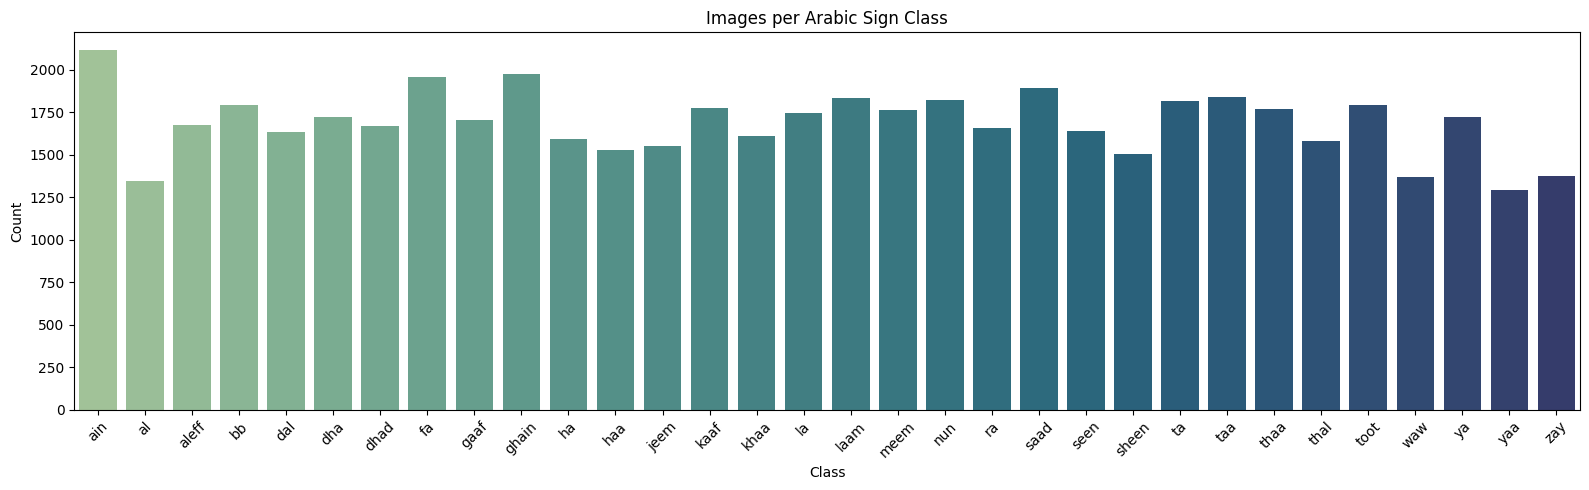

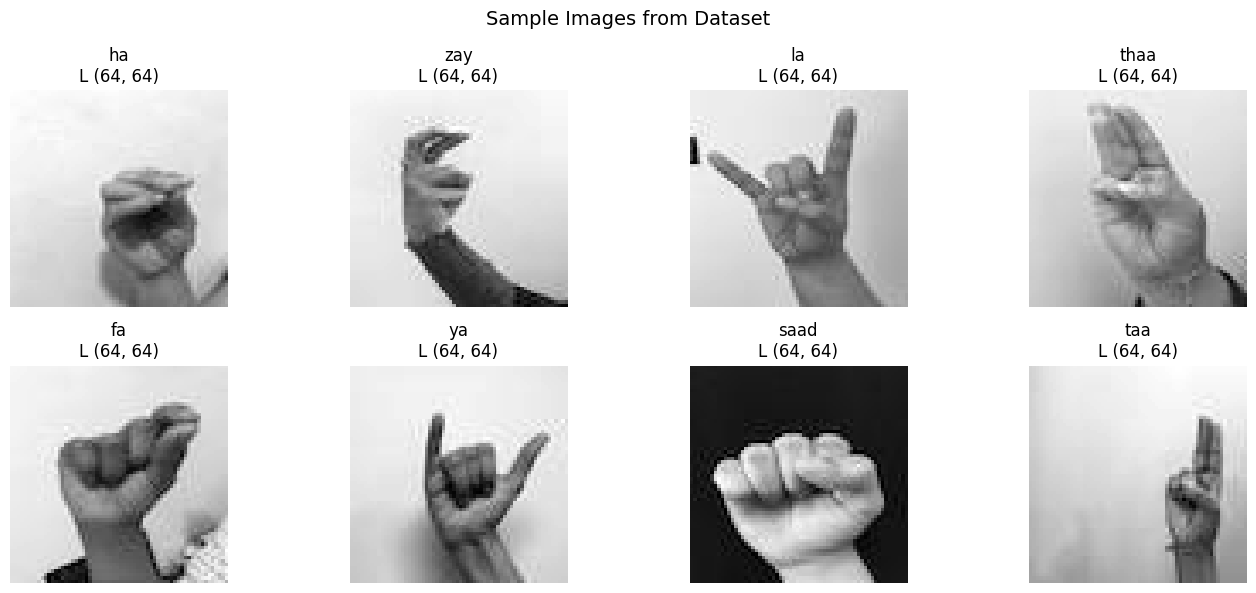

In [2]:
input_dir = '/kaggle/input'
class_info = []

for dirname, dirnames, filenames in os.walk(input_dir):
    if len(dirnames) == 0:
        images = [f for f in filenames if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if len(images) > 10:
            class_name = os.path.basename(dirname)
            
            # Sample one image to inspect it
            sample_path = os.path.join(dirname, images[0])
            img = Image.open(sample_path)
            
            class_info.append({
                'class': class_name,
                'count': len(images),
                'mode': img.mode,           # RGB, L, P, RGBA etc
                'size': img.size,           # (width, height)
            })

df = pd.DataFrame(class_info).sort_values('class').reset_index(drop=True)
print(f"Total classes: {len(df)}")
print(f"Total images: {df['count'].sum()}")
print(f"\nUnique image modes found: {df['mode'].unique()}")
print(f"Unique image sizes found: {df['size'].unique()}")
print(f"\n{df.to_string()}")

# Visualize class distribution
plt.figure(figsize=(16, 5))
sns.barplot(data=df, x='class', y='count', hue='class', palette='crest', legend=False)
plt.title('Images per Arabic Sign Class')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Visualize sample images from 8 random classes
sample_classes = random.sample(list(df['class']), min(8, len(df)))
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()

for i, cls in enumerate(sample_classes):
    # Find the folder for this class
    for dirname, dirnames, filenames in os.walk(input_dir):
        if os.path.basename(dirname) == cls and len(dirnames) == 0:
            img_path = os.path.join(dirname, random.choice(filenames))
            img = Image.open(img_path)
            axes[i].imshow(img, cmap='gray')
            axes[i].set_title(f'{cls}\n{img.mode} {img.size}')
            axes[i].axis('off')
            break

plt.suptitle('Sample Images from Dataset', fontsize=14)
plt.tight_layout()
plt.show()

Output shape: (64, 64, 1)
Min value:    0.0000
Max value:    1.0000
Dtype:        float32


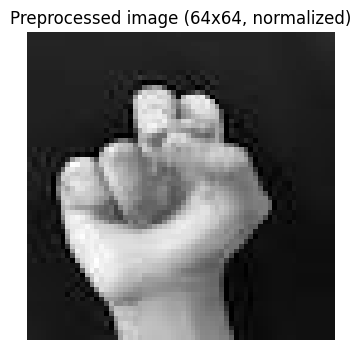

In [3]:
def preprocess_image(image_path, target_size=64):
    """
    Robust preprocessing for grayscale sign language images.
    
    Steps:
    1. Open image and force to true grayscale (handles RGB, P, RGBA, L)
    2. Validate pixel range and clip
    3. Letterbox pad to square (preserves aspect ratio, no squashing)
    4. Resize to target_size x target_size
    5. Return as numpy array with shape (target_size, target_size, 1)
    """
    img = Image.open(image_path)
    
    # Step 1: Force to grayscale regardless of source mode
    # This handles: L (already gray), RGB (3 identical channels), 
    # P (palette), RGBA (with alpha), and any corrupted mode
    img = img.convert('L')
    
    # Step 2: Pixel validation — clip any out-of-range values
    img_array = np.array(img, dtype=np.float32)
    img_array = np.clip(img_array, 0, 255)
    img = Image.fromarray(img_array.astype(np.uint8))
    
    # Step 3: Letterbox pad to square (black padding)
    # This preserves the hand shape — no stretching distortion
    w, h = img.size
    max_dim = max(w, h)
    pad_left = (max_dim - w) // 2
    pad_top  = (max_dim - h) // 2
    
    square_img = Image.new('L', (max_dim, max_dim), color=0)  # black background
    square_img.paste(img, (pad_left, pad_top))
    
    # Step 4: Resize to target
    square_img = square_img.resize((target_size, target_size), Image.LANCZOS)
    
    # Step 5: Return as (H, W, 1) float32 array
    final_array = np.array(square_img, dtype=np.float32)
    final_array = final_array / 255.0          # normalize to [0, 1]
    final_array = np.expand_dims(final_array, axis=-1)  # add channel dim
    
    return final_array

# Test it on one image
test_path = None
for dirname, dirnames, filenames in os.walk(input_dir):
    if len(dirnames) == 0:
        images = [f for f in filenames if f.lower().endswith(('.png','.jpg','.jpeg'))]
        if images:
            test_path = os.path.join(dirname, images[0])
            break

result = preprocess_image(test_path)
print(f"Output shape: {result.shape}")        # should be (64, 64, 1)
print(f"Min value:    {result.min():.4f}")    # should be 0.0
print(f"Max value:    {result.max():.4f}")    # should be ~1.0
print(f"Dtype:        {result.dtype}")        # float32

plt.figure(figsize=(4, 4))
plt.imshow(result[:, :, 0], cmap='gray')
plt.title('Preprocessed image (64x64, normalized)')
plt.axis('off')
plt.show()

In [4]:
TARGET_SIZE = 64
BATCH_SIZE  = 32
output_dir  = '/kaggle/working/arasl_processed'

# Collect all valid classes
valid_classes = {}
for dirname, dirnames, filenames in os.walk(input_dir):
    if len(dirnames) == 0:
        images = [f for f in filenames if f.lower().endswith(('.png','.jpg','.jpeg'))]
        if len(images) > 10:
            class_name = os.path.basename(dirname)
            valid_classes[class_name] = [os.path.join(dirname, f) for f in images]

class_names = sorted(valid_classes.keys())
class_to_idx = {name: i for i, name in enumerate(class_names)}
num_classes  = len(class_names)

print(f"Classes found: {num_classes}")
print(f"Class mapping: {class_to_idx}")

# Load and preprocess everything into memory
# (dataset is small enough to fit in Kaggle RAM)
X_all, y_all = [], []
failed = 0

for class_name, paths in tqdm(valid_classes.items(), desc="Loading classes"):
    label = class_to_idx[class_name]
    for path in paths:
        try:
            arr = preprocess_image(path, target_size=TARGET_SIZE)
            X_all.append(arr)
            y_all.append(label)
        except Exception as e:
            failed += 1

X_all = np.array(X_all, dtype=np.float32)
y_all = np.array(y_all, dtype=np.int32)

print(f"\nDataset shape: {X_all.shape}")   # (N, 64, 64, 1)
print(f"Labels shape:  {y_all.shape}")
print(f"Failed loads:  {failed}")
print(f"Value range:   [{X_all.min():.3f}, {X_all.max():.3f}]")

Classes found: 32
Class mapping: {'ain': 0, 'al': 1, 'aleff': 2, 'bb': 3, 'dal': 4, 'dha': 5, 'dhad': 6, 'fa': 7, 'gaaf': 8, 'ghain': 9, 'ha': 10, 'haa': 11, 'jeem': 12, 'kaaf': 13, 'khaa': 14, 'la': 15, 'laam': 16, 'meem': 17, 'nun': 18, 'ra': 19, 'saad': 20, 'seen': 21, 'sheen': 22, 'ta': 23, 'taa': 24, 'thaa': 25, 'thal': 26, 'toot': 27, 'waw': 28, 'ya': 29, 'yaa': 30, 'zay': 31}


Loading classes: 100%|██████████| 32/32 [03:38<00:00,  6.82s/it]



Dataset shape: (54049, 64, 64, 1)
Labels shape:  (54049,)
Failed loads:  0
Value range:   [0.000, 1.000]


In [6]:
from sklearn.model_selection import train_test_split

# Split
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all,
    test_size=0.20,
    random_state=42,
    stratify=y_all
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(f"Train: {X_train.shape[0]} images")
print(f"Val:   {X_val.shape[0]} images")
print(f"Test:  {X_test.shape[0]} images")

# ── Define augmentation layers ONCE outside the map function ──
aug_rotation    = tf.keras.layers.RandomRotation(0.05, seed=42)
aug_zoom        = tf.keras.layers.RandomZoom(0.10, seed=42)
aug_translation = tf.keras.layers.RandomTranslation(0.10, 0.10, seed=42)

def augment(image, label):
    image = tf.image.random_flip_left_right(image, seed=42)
    image = tf.image.random_brightness(image, max_delta=0.2, seed=42)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2, seed=42)
    # Call the pre-built layers — no new Variables created inside the trace
    image = aug_rotation(image, training=True)
    image = aug_zoom(image, training=True)
    image = aug_translation(image, training=True)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label

def make_dataset(X, y, augment_fn=None, batch_size=32):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if augment_fn is not None:
        ds = ds.map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(X_train, y_train, augment_fn=augment, batch_size=BATCH_SIZE)
val_ds   = make_dataset(X_val,   y_val,   augment_fn=None,    batch_size=BATCH_SIZE)
test_ds  = make_dataset(X_test,  y_test,  augment_fn=None,    batch_size=BATCH_SIZE)

print("Datasets ready.")

Train: 43239 images
Val:   5405 images
Test:  5405 images
Datasets ready.


In [7]:
def build_arsl_cnn(input_shape=(64, 64, 1), num_classes=32):
    """
    Custom CNN designed for grayscale Arabic sign language recognition.
    
    Architecture logic:
    - 3 conv blocks with increasing filters (32 → 64 → 128)
    - BatchNorm after each conv (stabilizes training, acts as regularizer)
    - MaxPool halves spatial dims each block (64 → 32 → 16 → 8)
    - Dropout before Dense layers (prevents overfitting)
    - Two Dense layers before final softmax
    """
    model = models.Sequential([
        # Input
        layers.Input(shape=input_shape),
        
        # Block 1 — edge and texture detection
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 2 — shape and part detection
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 3 — high-level sign features
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.35),
        
        # Classifier head
        layers.GlobalAveragePooling2D(),  # better than Flatten for generalization
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ], name="ArSL_CNN")
    
    return model

model = build_arsl_cnn(input_shape=(TARGET_SIZE, TARGET_SIZE, 1), num_classes=num_classes)
model.summary()

# Verify output shape
dummy = np.zeros((1, TARGET_SIZE, TARGET_SIZE, 1), dtype=np.float32)
out = model(dummy)
print(f"\nOutput shape: {out.shape}")   # should be (1, 32)

Model: "ArSL_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 330,496 (1.26 MB)

 Trainable params: 329,088 (1.26 MB)

 Non-trainable params: 1,408 (5.50 KB)

I0000 00:00:1780687397.206147      58 cuda_dnn.cc:529] Loaded cuDNN version 91002



Output shape: (1, 32)


In [8]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,         # halve the learning rate when stuck
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50


I0000 00:00:1780687418.756661     154 service.cc:152] XLA service 0x78356c002d70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780687418.756706     154 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780687418.756712     154 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
2026-06-05 19:23:41.511651: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 19:23:41.653915: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


   5/1352 ━━━━━━━━━━━━━━━━━━━━ 41s 31ms/step - accuracy: 0.0220 - loss: 4.3943 

I0000 00:00:1780687427.463684     154 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1349/1352 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.1426 - loss: 3.4163

2026-06-05 19:24:25.761053: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 19:24:25.899637: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1352/1352 ━━━━━━━━━━━━━━━━━━━━ 61s 34ms/step - accuracy: 0.3062 - loss: 2.4855 - val_accuracy: 0.3954 - val_loss: 2.1200 - learning_rate: 0.0010
Epoch 2/50
1352/1352 ━━━━━━━━━━━━━━━━━━━━ 38s 28ms/step - accuracy: 0.7024 - loss: 0.9102 - val_accuracy: 0.7088 - val_loss: 0.8615 - learning_rate: 0.0010
Epoch 3/50
1352/1352 ━━━━━━━━━━━━━━━━━━━━ 38s 28ms/step - accuracy: 0.7965 - loss: 0.6199 - val_accuracy: 0.7099 - val_loss: 0.9157 - learning_rate: 0.0010
Epoch 4/50
1352/1352 ━━━━━━━━━━━━━━━━━━━━ 37s 27ms/step - accuracy: 0.8430 - loss: 0.4833 - val_accuracy: 0.8773 - val_loss: 0.3683 - learning_rate: 0.0010
Epoch 5/50
1352/1352 ━━━━━━━━━━━━━━━━━━━━ 38s 27ms/step - accuracy: 0.8697 - loss: 0.4053 - val_accuracy: 0.9151 - val_loss: 0.2675 - learning_rate: 0.0010
Epoch 6/50
1352/1352 ━━━━━━━━━━━━━━━━━━━━ 37s 27ms/step - accuracy: 0.8867 - loss: 0.3525 - val_accuracy: 0.8977 - val_loss: 0.3120 - learning_rate: 0.0010
Epoch 7/50
1352/1352 ━━━━━━━━━━━━━━━━━━━━ 38s 28ms/step - accuracy: 0.8993 

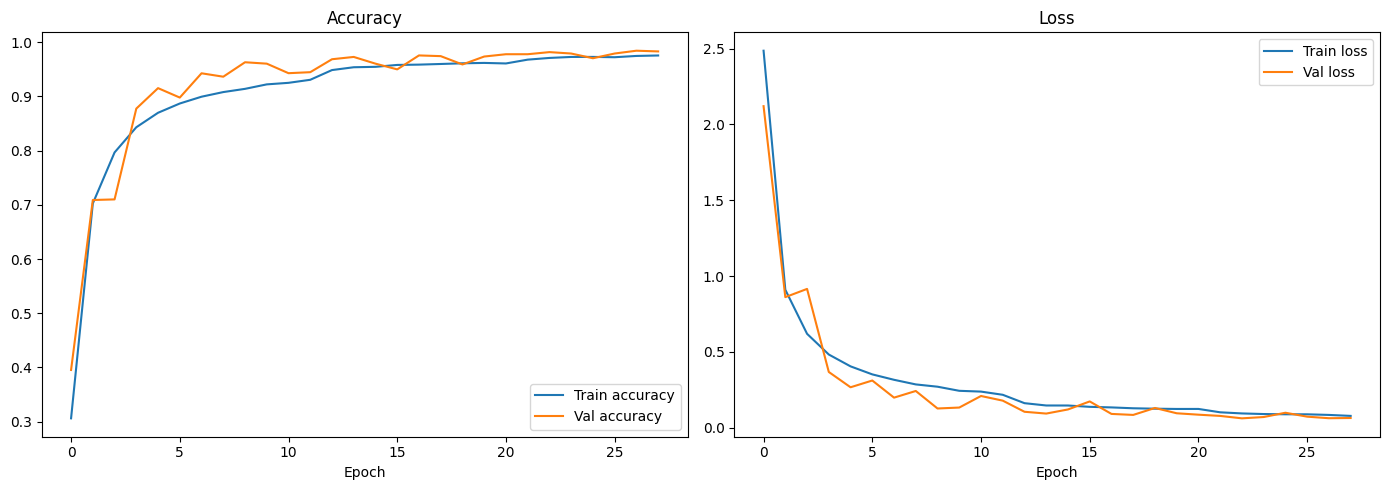

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'],     label='Train accuracy')
ax1.plot(history.history['val_accuracy'], label='Val accuracy')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history.history['loss'],     label='Train loss')
ax2.plot(history.history['val_loss'], label='Val loss')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()

169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9837 - loss: 0.0476

Test Accuracy: 98.37%
Test Loss:     0.0476

Sanity check — unique true labels:  32
Sanity check — unique pred labels:  32

Classification Report:
              precision    recall  f1-score   support

         ain       0.99      1.00      0.99       211
          al       0.96      1.00      0.98       134
       aleff       0.98      1.00      0.99       167
          bb       1.00      0.99      1.00       179
         dal       0.99      0.93      0.96       163
         dha       0.96      0.98      0.97       172
        dhad       0.99      1.00      1.00       167
          fa       0.99      0.94      0.96       196
        gaaf       0.92      0.99      0.95       171
       ghain       0.99      0.98      0.99       198
          ha       0.98      0.97      0.97       159
         haa       0.97      0.99      0.98       152
        jeem       0.98      0.99      0.99       155
        kaaf       0

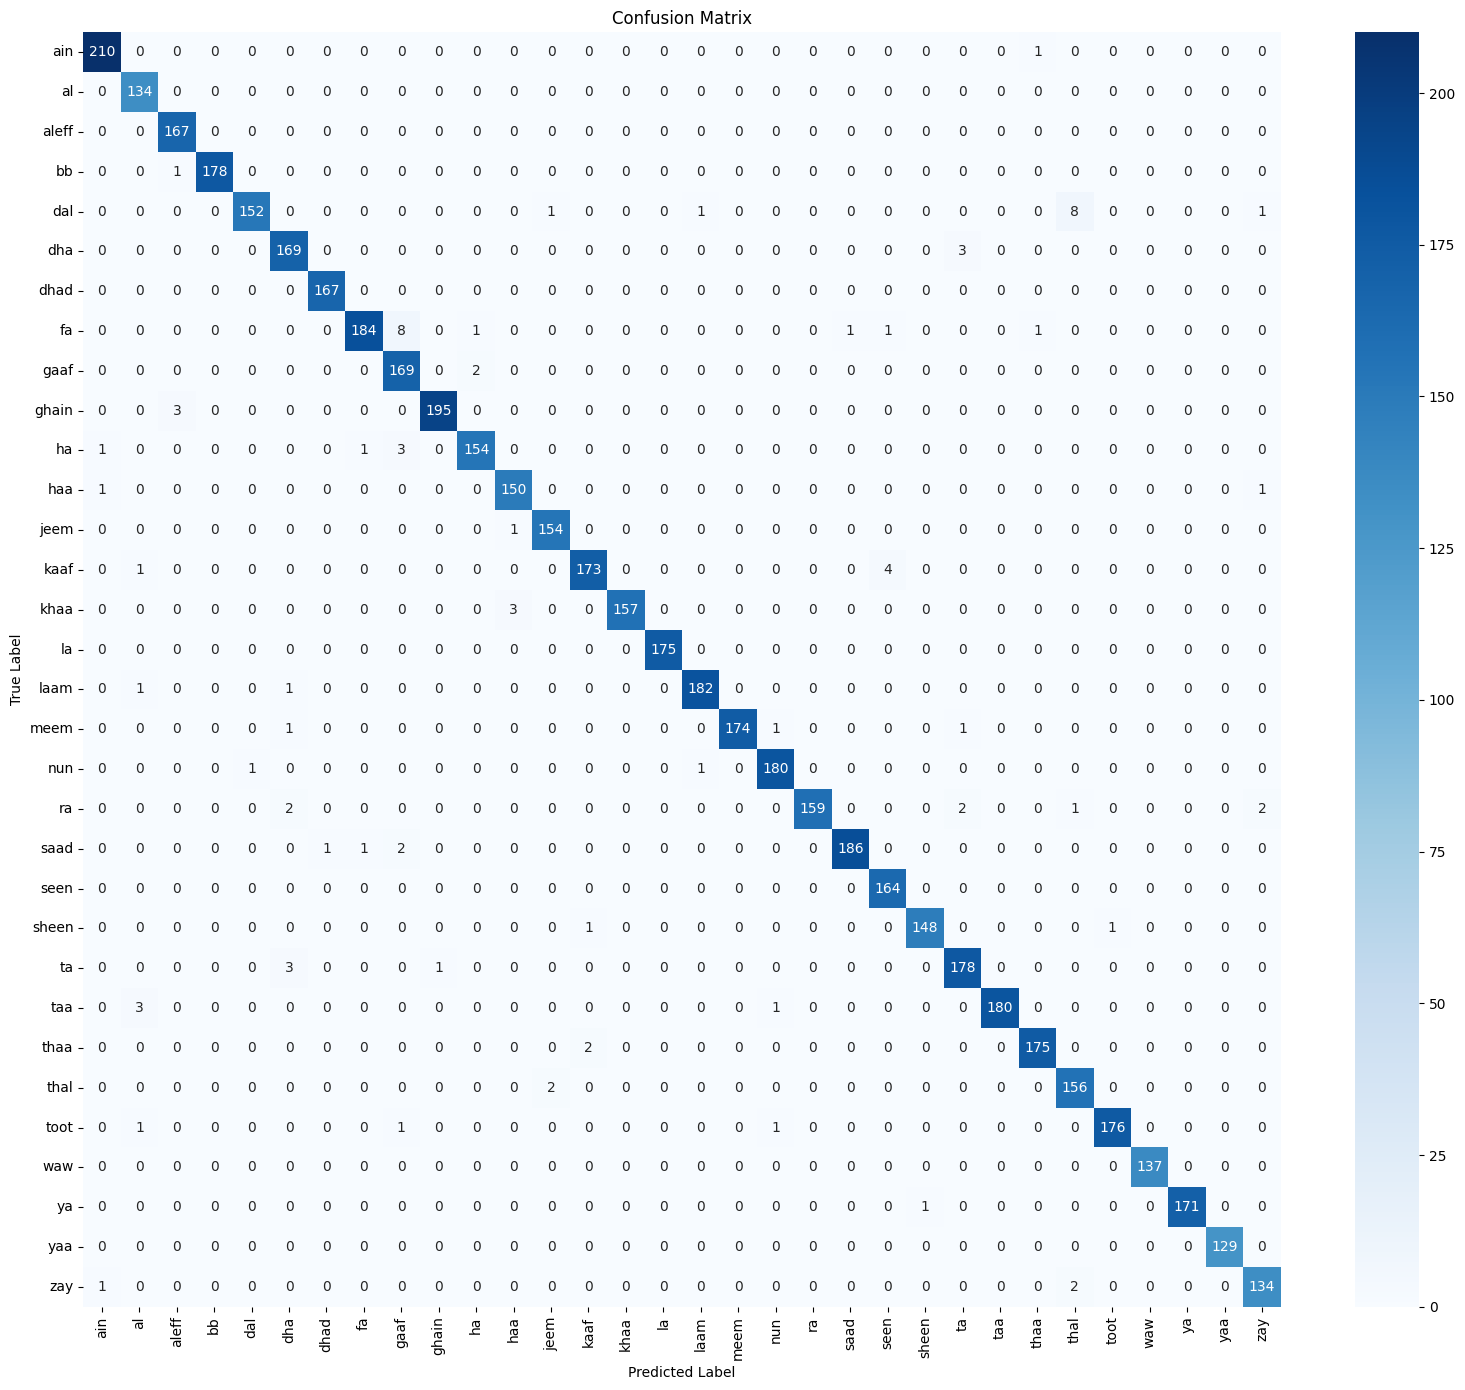

In [12]:
from sklearn.metrics import classification_report, confusion_matrix

test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTest Accuracy: {test_acc * 100:.2f}%")
print(f"Test Loss:     {test_loss:.4f}")

# ── Extract y_true and y_pred from the SAME dataset in the SAME order ──
y_true_list = []
y_pred_list = []

for X_batch, y_batch in test_ds:
    preds = model.predict(X_batch, verbose=0)
    y_pred_list.extend(np.argmax(preds, axis=1))
    y_true_list.extend(y_batch.numpy())

y_true = np.array(y_true_list)
y_pred = np.array(y_pred_list)

print(f"\nSanity check — unique true labels:  {len(np.unique(y_true))}")
print(f"Sanity check — unique pred labels:  {len(np.unique(y_pred))}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [13]:
import json

model.save('arsl_cnn_model.keras')

# Save class names so the server uses the exact same order
with open('class_names.json', 'w', encoding='utf-8') as f:
    json.dump(class_names, f, ensure_ascii=False, indent=2)

print("Saved: arsl_cnn_model.keras")
print("Saved: class_names.json")
print(f"Class order: {class_names}")

Saved: arsl_cnn_model.keras
Saved: class_names.json
Class order: ['ain', 'al', 'aleff', 'bb', 'dal', 'dha', 'dhad', 'fa', 'gaaf', 'ghain', 'ha', 'haa', 'jeem', 'kaaf', 'khaa', 'la', 'laam', 'meem', 'nun', 'ra', 'saad', 'seen', 'sheen', 'ta', 'taa', 'thaa', 'thal', 'toot', 'waw', 'ya', 'yaa', 'zay']


In [14]:
from IPython.display import FileLink

FileLink('arsl_cnn_model.keras')

/kaggle/working/arsl_cnn_model.keras